In [1]:
from admmcolinviz import ADMMColin, _plot_control_tripcolor
from matplotlib import pyplot as plt
import numpy as np
from subproblem2_solver import Subproblem2Solver
from subproblem1_solver import Subproblem1Solver

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
admm_1 = ADMMColin(alpha=1.0, dim=64, base_dir="run_data_admm_gurobi")

In [8]:
admm_01 = ADMMColin(alpha=0.1, dim=64, base_dir="run_data_admm_gurobi")

In [16]:
admm_001 = ADMMColin(alpha=0.01, dim=64, base_dir="run_data_admm_gurobi")

In [23]:
b_001 = admm_001.trial(0).iters.control_cont[1]

In [24]:
b_01 = admm_01.trial(0).iters.control_cont[1]

In [25]:
b_1 = admm_1.trial(0).iters.control_cont[1]

In [14]:
b_01.flatten().sum()/len(b_01.flatten())

0.4000000004953581

In [15]:
b_1.flatten().sum()/len(b_1.flatten())

0.399999999661761

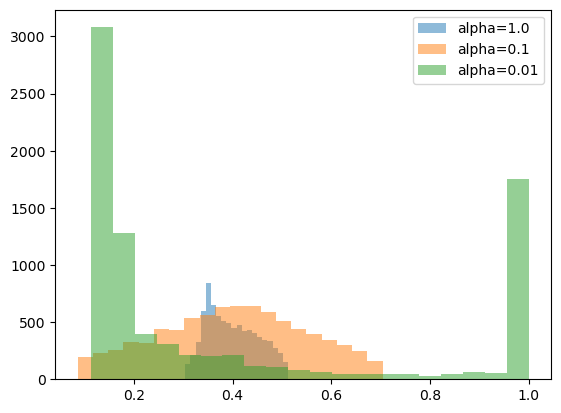

In [26]:
plt.hist(b_1.flatten(), bins=20, alpha=0.5, label="alpha=1.0")
plt.hist(b_01.flatten(), bins=20, alpha=0.5, label="alpha=0.1")
plt.hist(b_001.flatten(), bins=20, alpha=0.5, label="alpha=0.01")

plt.legend()
plt.show()

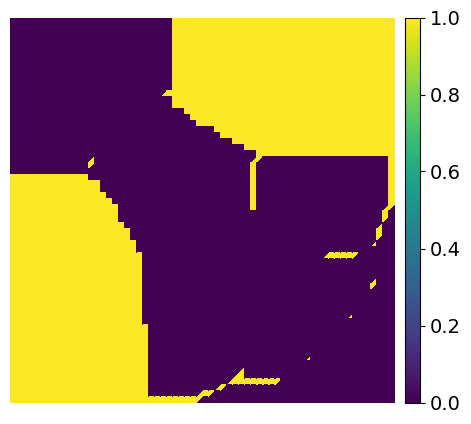

In [3]:
admm.plot_control()

In [12]:
admm.trial(0).series.objective[1:]

array([18.11538836,  6.64771192,  2.66971745,  2.6009038 ,  2.57744198,
        2.45857292,  2.49943704,  2.56204306,  2.51246072,  2.66411475,
        2.5640991 ,  2.38702016,  2.60580782,  2.52524387,  2.3917498 ])

In [10]:
admm.trial(2).iters.oc_iters.F

IndexError: list index out of range

In [61]:
i=0
j=4
X = admm.trial(0).iters.oc_iters[i].gradF[j]

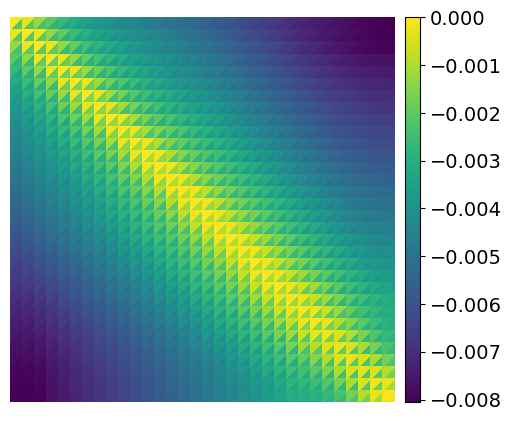

In [62]:
admm.plot_control(X)

In [60]:
# ADMMColin-specific helpers: OC objective F(b^k) and OC gradient grids
import numpy as np
import matplotlib.pyplot as plt
from admmcolinviz import _plot_control_tripcolor, _transpose_control_triangles

def plot_colin_oc_F(admm_colin, trial_idx, oc_iter_idx=None,
                    ax=None, figsize=(7, 4), color="#1f77b4"):

    oc_iters = admm_colin.trial(trial_idx).iters.oc_iters

    if len(oc_iters) == 0:
        raise ValueError(f"No OC iterations found for trial {trial_idx}.")

    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if oc_iter_idx is None:
        y = []
        x = np.arange(len(oc_iters))
        for oc in oc_iters:
            f_arr = np.asarray(oc.F, dtype=float).ravel()
            y.append(float(f_arr[-1]) if f_arr.size > 0 else np.nan)

        y = np.asarray(y, dtype=float)
        valid = np.isfinite(y)

        ax.plot(x[valid], y[valid], color=color, linewidth=2.2,
                marker="o", markersize=4)

        ax.set_title(f"Trial {trial_idx}", fontsize=12, fontweight="bold")
        ax.set_xlabel("OC iteration", fontsize=10)

    else:
        f_arr = np.asarray(oc_iters[oc_iter_idx].F, dtype=float).ravel()
        x = np.arange(f_arr.size)

        if f_arr.size == 1:
            ax.scatter(x, f_arr, color=color, s=40)
        else:
            ax.plot(x, f_arr, color=color, linewidth=2.2,
                    marker="o", markersize=4)

        ax.set_title(f"OC iter {oc_iter_idx}", fontsize=12)
        ax.set_xlabel("OC iter (k)", fontsize=10)

    ax.set_ylabel(r"$F(b^{k})$", fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_axisbelow(True)

    return ax 


def plot_colin_oc_gradients_grid(
    admm_colin,
    trial_idx,
    oc_iter_idx,
    grad_start=0,
    grad_end=None,
    ncols=8,
    cmap="viridis",
    fix_diagonal_reflection=True,
    panel_size=(1.9, 1.9),
    title_fontsize=7,
    show_colorbar=True,
    colorbar_label=r"$\nabla_v^k F(v^k)$",
):
    """
    Plot selected gradF entries X = gradF[grad_start:grad_end] in a tight 8-column grid.

    Each panel uses the same triangle-control rendering as admm.plot_control(X).
    """
    oc_iters = admm_colin.trial(trial_idx).iters.oc_iters
    #oc_iters = admm_colin.trial(trial_idx).iters.control
    if oc_iter_idx < 0 or oc_iter_idx >= len(oc_iters):
        raise IndexError(f"oc_iter_idx {oc_iter_idx} out of range [0, {len(oc_iters)-1}].")

    grads = list(oc_iters[oc_iter_idx].gradF)
    #grads = list(oc_iters)
    if grad_end is None:
        grad_end = len(grads)

    if grad_start < 0 or grad_end < grad_start or grad_end > len(grads):
        raise IndexError(
            f"Invalid grad slice [{grad_start}:{grad_end}] for gradF length {len(grads)}."
        )

    selected = grads[grad_start:grad_end]
    total = len(selected)
    if total == 0:
        raise ValueError("No gradients selected. Check grad_start/grad_end.")

    # Global color range for consistent comparison across panels.
    all_vals = []
    for X in selected:
        a = np.asarray(X, dtype=float).ravel()
        if fix_diagonal_reflection:
            a = _transpose_control_triangles(a, admm_colin.dim)
        all_vals.append(a)
    vmin = min(np.min(a) for a in all_vals)
    vmax = max(np.max(a) for a in all_vals)

    nrows = int(np.ceil(total / ncols))
    fig_w = panel_size[0] * ncols
    fig_h = panel_size[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)

    last_im = None
    for idx, X in enumerate(selected):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        a = np.asarray(X, dtype=float).ravel()

        if fix_diagonal_reflection:
            a = _transpose_control_triangles(a, admm_colin.dim)

        im = _plot_control_tripcolor(ax, admm_colin.dim, a, title="", cmap=cmap)
        im.set_clim(vmin=vmin, vmax=vmax)
        last_im = im

        ax.set_axis_off()
        k = grad_start + idx
        ax.set_title(rf"$\nabla_v^{{{k}}} F(v^{{{k}}})$", fontsize=title_fontsize, pad=0.5)

    # Hide unused panels.
    for idx in range(total, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r, c].set_axis_off()

    # Reserve a dedicated strip on the right for colorbar (prevents overlap).
    plt.subplots_adjust(
        left=0.003,
        right=0.93,
        bottom=0.003,
        top=0.992,
        wspace=0.04,
        hspace=0.10,
    )

    if show_colorbar and last_im is not None:
        cax = fig.add_axes([0.94, 0.06, 0.018, 0.88])
        cbar = fig.colorbar(last_im, cax=cax)
        cbar.set_label(colorbar_label, fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    plt.show()


## Example usage:
## admm_colin = ADMMColin(alpha=0.1, dim=32, base_dir="admm_colin/run_data_admm_mergesplit")
## plot_colin_oc_F(admm_colin, trial_idx=0)
## plot_colin_oc_F(admm_colin, trial_idx=0, oc_iter_idx=4)
## plot_colin_oc_gradients_grid(admm_colin, trial_idx=0, oc_iter_idx=4, grad_start=2, grad_end=18)

In [10]:
admm_colin = ADMMColin(alpha=0.1, dim=64, base_dir="run_data_admm_gurobi")

In [ ]:
trials = (admm_colin.trial(0).iters.oc_iters.F)
n = min(18, len(trials))
cols = 6
rows = int(np.ceil(n / cols))

KeyError: "Seed group 'seed_6' not found. Available: ['seed_0', 'summary']"

In [12]:
fig, axes = plt.subplots(rows, cols, figsize=(18, 3 * rows))
axes = axes.flatten()

for i in range(min(18,n)):
    plot_colin_oc_F(admm_colin, trial_idx=0, oc_iter_idx=i, ax=axes[i])

# remove unused axes
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1800x0 with 0 Axes>

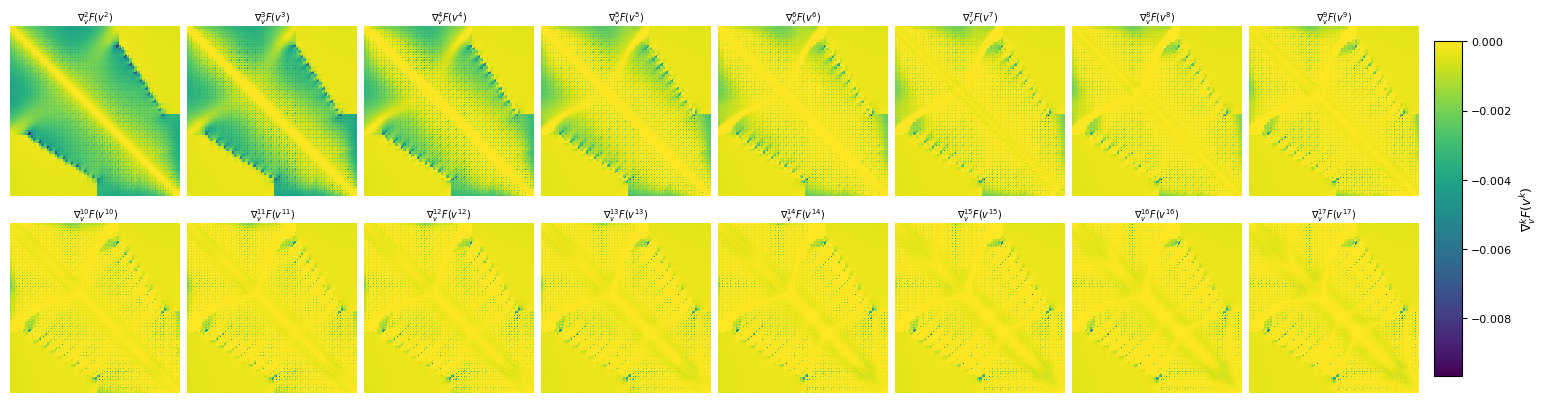

In [84]:
plot_colin_oc_gradients_grid(
admm_colin,
trial_idx=0,
oc_iter_idx=1,
grad_start=2,
grad_end=18
)

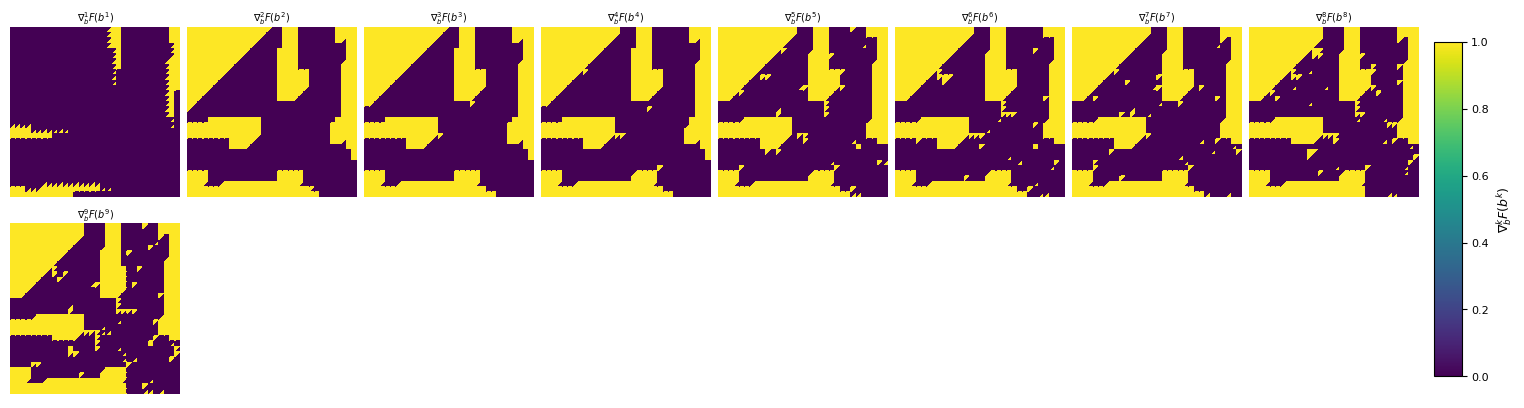

In [59]:
plot_colin_oc_gradients_grid(
admm_colin,
trial_idx=0,
oc_iter_idx=1,
grad_start=1,
grad_end=10
)

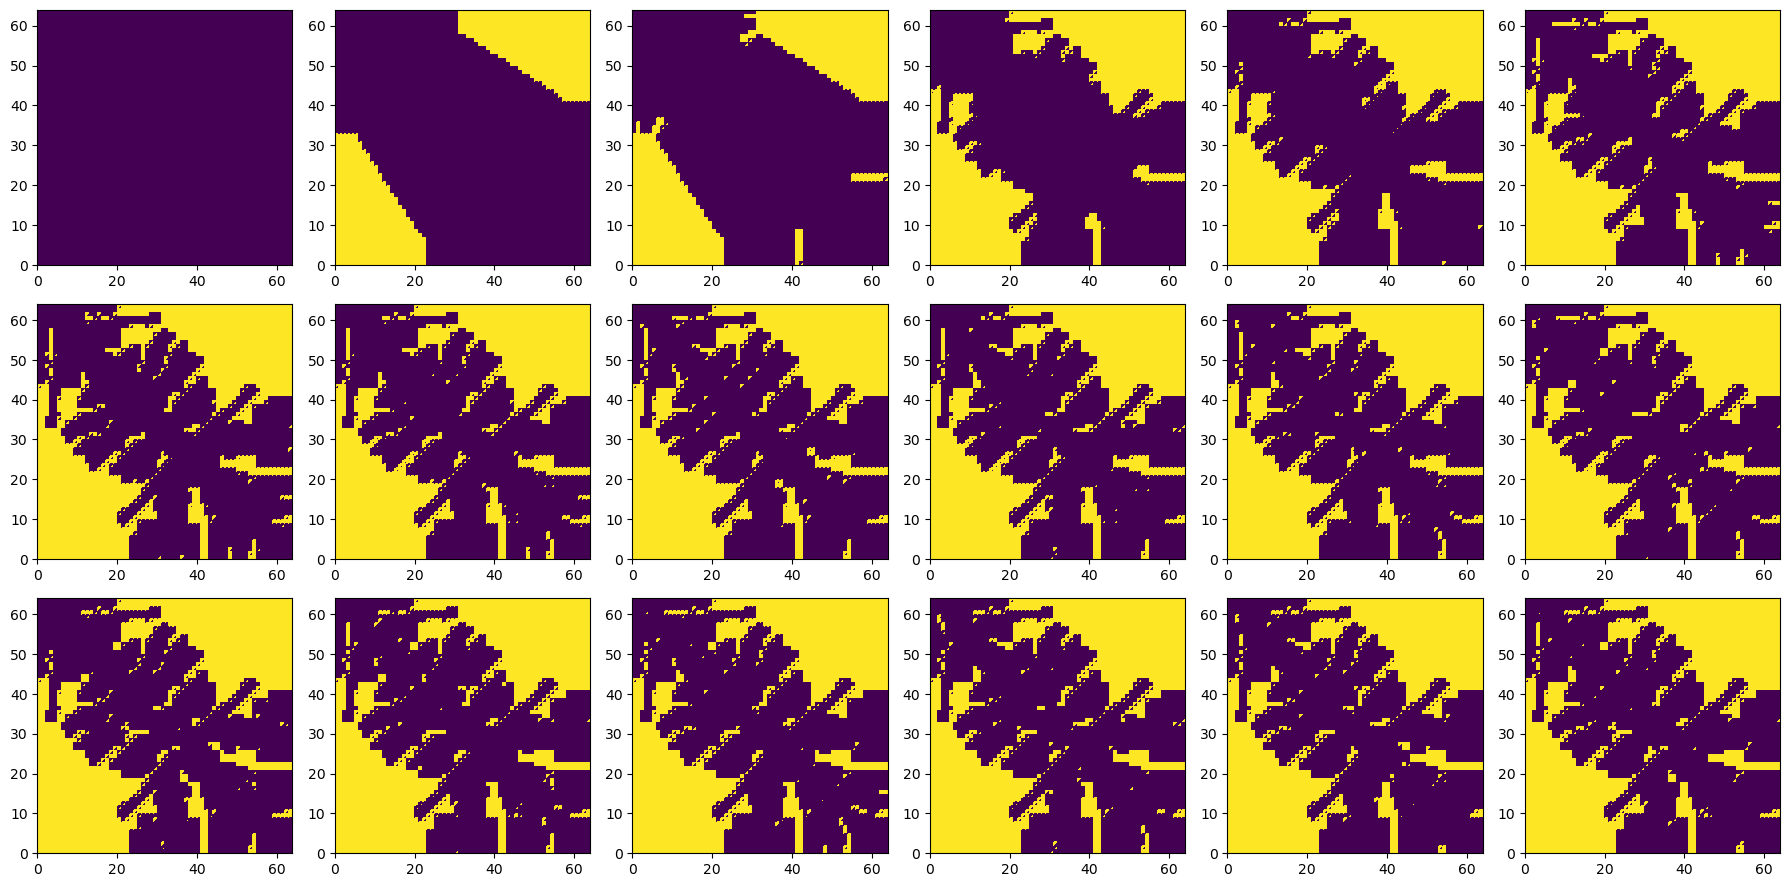

In [92]:
fig, axes = plt.subplots(rows, cols, figsize=(18, 3 * rows))
axes = axes.flatten()

for i in range(min(18, admm_colin.trial(0).iters.control.shape[0])):
    _plot_control_tripcolor(axes[i], 64, admm_colin.trial(0).iters.control[i], title=f"Control iter {i}")

# remove unused axes
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()